# 2.5 Visual Weather Systems CNN

## Table of Contents
## 1.Import Libraries and Data
## 2. CNN Model 1
### 2.1 Evaluate Model
## 3. CNN Model 2
### 3.1 Evaluate Model
## 4. CNN Model 3
### 4.1 Evaluate Model
## 5. CNN Model 4
### 5.1 Evaluate Model
## 6. CNN Model 5
### 6.1 Evaluate Model

## 1. Import Libraries and Data

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation
from keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [12]:
#download the weather images and put them in a directory
path = r'/Users/daxma/OneDrive/Desktop/Data Analytics/Machine Learning with Python/07-25 ClimateWins Analysis/02 Data/Original Data/archive/Multi-class Weather Dataset'
folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', 'Shine', 'Sunrise']


In [14]:
#this will load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 631 images belonging to 4 classes.
Found 157 images belonging to 4 classes.


## 2. CNN Model 1

In [18]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [20]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 7, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

C:\Users\daxma\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/7
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 526ms/step - accuracy: 0.4190 - loss: 0.1696 - val_accuracy: 0.4531 - val_loss: 0.1745
Epoch 2/7
 1/19 ━━━━━━━━━━━━━━━━━━━━ 7s 395ms/step - accuracy: 0.6250 - loss: 0.1284

C:\Users\daxma\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6250 - loss: 0.1284 - val_accuracy: 0.5312 - val_loss: 0.1478
Epoch 3/7
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 476ms/step - accuracy: 0.6561 - loss: 0.1187 - val_accuracy: 0.7109 - val_loss: 0.1192
Epoch 4/7
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.7500 - loss: 0.1094 - val_accuracy: 0.6562 - val_loss: 0.1327
Epoch 5/7
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 454ms/step - accuracy: 0.7513 - loss: 0.0915 - val_accuracy: 0.6797 - val_loss: 0.1274
Epoch 6/7
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9062 - loss: 0.0467 - val_accuracy: 0.7109 - val_loss: 0.1260
Epoch 7/7
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.8063 - loss: 0.0731 - val_accuracy: 0.6562 - val_loss: 0.1395


In [21]:
results = pd.DataFrame(model.history.history)

## 2.1 Evaluate Model

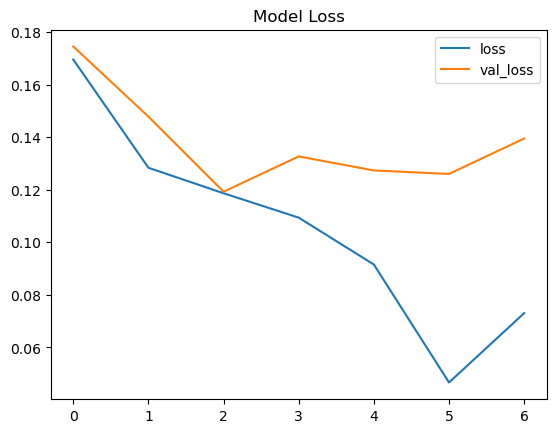

In [25]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

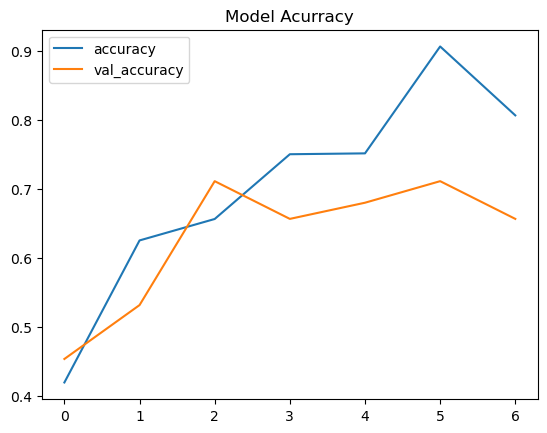

In [27]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [29]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.8063439130783081, Val_Accuracy: 0.65625
Loss: 0.07305546849966049, Val_Loss: 0.13951227068901062


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step


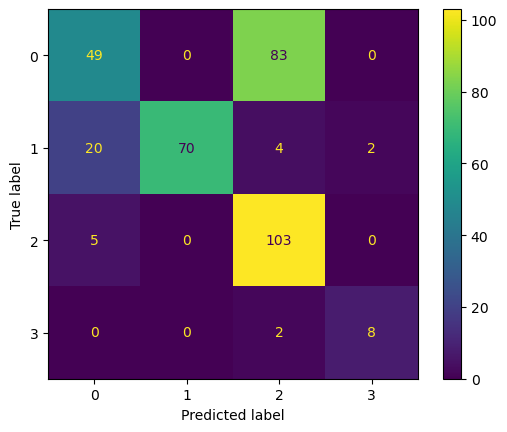

In [31]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [33]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


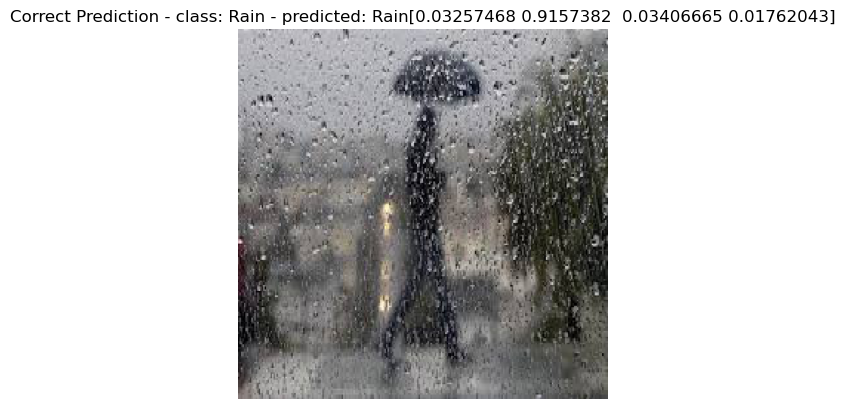

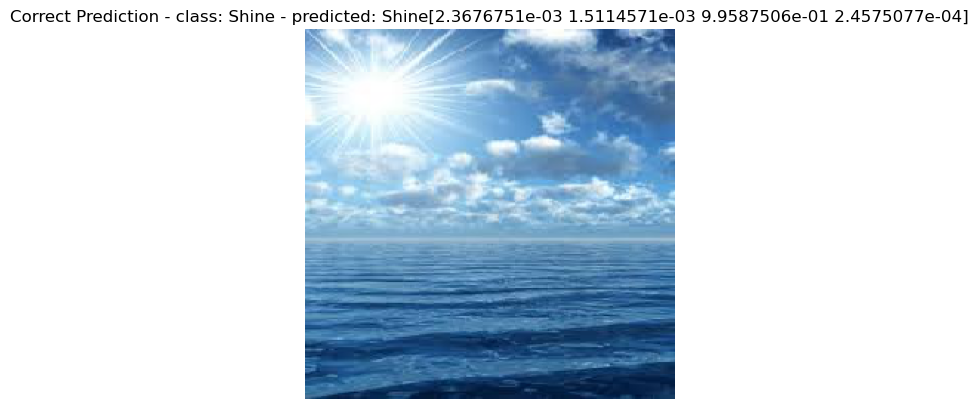

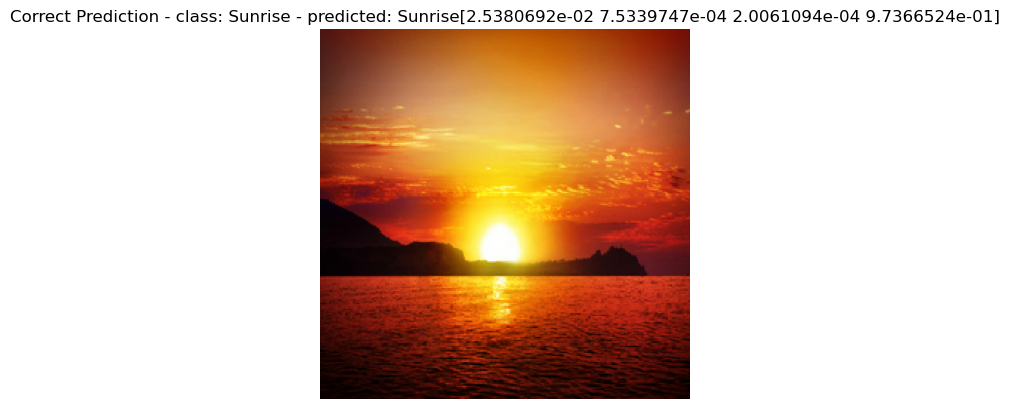

In [35]:
predict_one(model, 3) #<--you can show multiple pictures with this command. Just fill in the number you want to see.

## 3. CNN Model 2

In [41]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [43]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 30, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 516ms/step - accuracy: 0.4708 - loss: 0.1570 - val_accuracy: 0.5781 - val_loss: 0.1538
Epoch 2/30
 1/19 ━━━━━━━━━━━━━━━━━━━━ 6s 384ms/step - accuracy: 0.5938 - loss: 0.1476

C:\Users\daxma\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.5938 - loss: 0.1476 - val_accuracy: 0.6016 - val_loss: 0.1419
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 493ms/step - accuracy: 0.7279 - loss: 0.1011 - val_accuracy: 0.6562 - val_loss: 0.1382
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.7500 - loss: 0.1111 - val_accuracy: 0.5781 - val_loss: 0.1694
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 456ms/step - accuracy: 0.7579 - loss: 0.0949 - val_accuracy: 0.6797 - val_loss: 0.1201
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.8750 - loss: 0.0529 - val_accuracy: 0.7422 - val_loss: 0.1119
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 504ms/step - accuracy: 0.7346 - loss: 0.1012 - val_accuracy: 0.6875 - val_loss: 0.1248
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9375 - loss: 0.0533 - val_accuracy: 0.7031 - val_loss: 0.1117
Epoch 9/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 517ms/step - accuracy: 0.7930 - loss: 0.0789 - val_accuracy: 0.7109 - val_lo

In [44]:
results = pd.DataFrame(model.history.history)

## 3.1 Evaluate Model

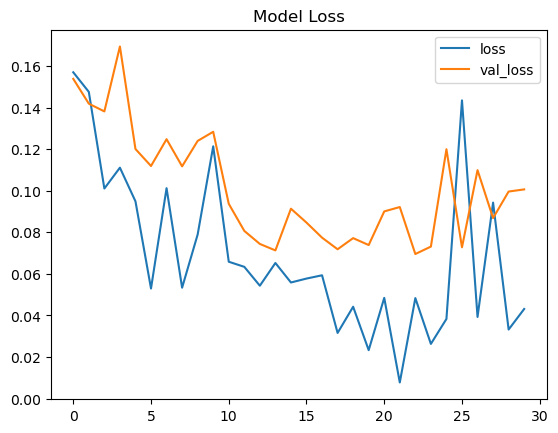

In [46]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

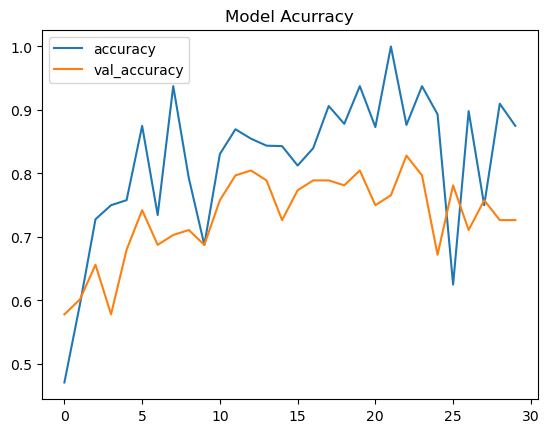

In [47]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [48]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.875, Val_Accuracy: 0.7265625
Loss: 0.043099887669086456, Val_Loss: 0.10064668208360672


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step


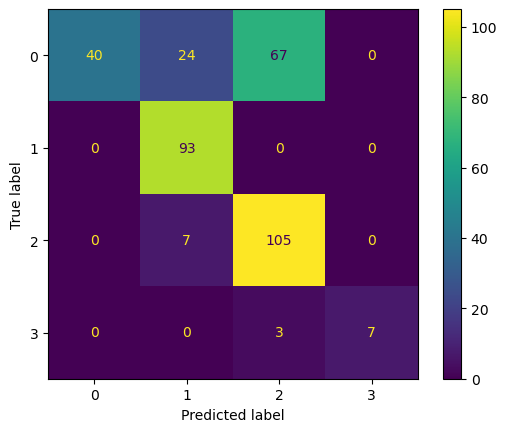

In [49]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [50]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


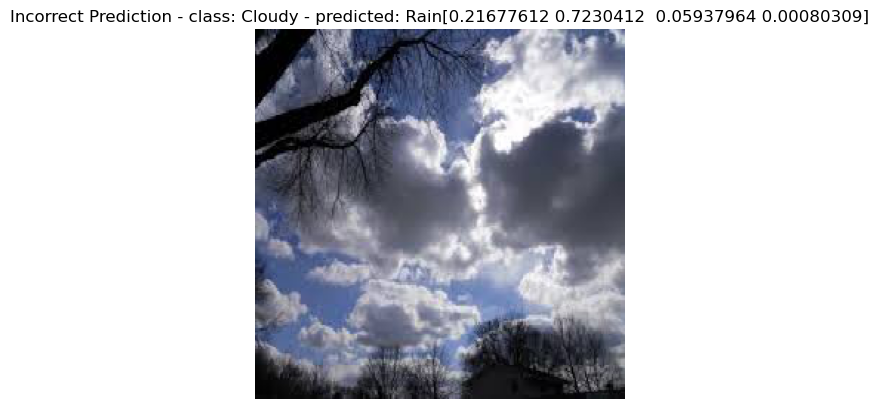

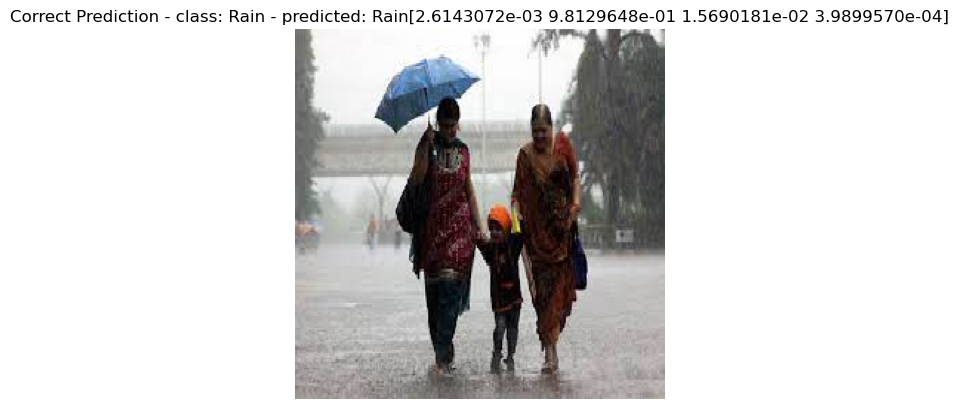

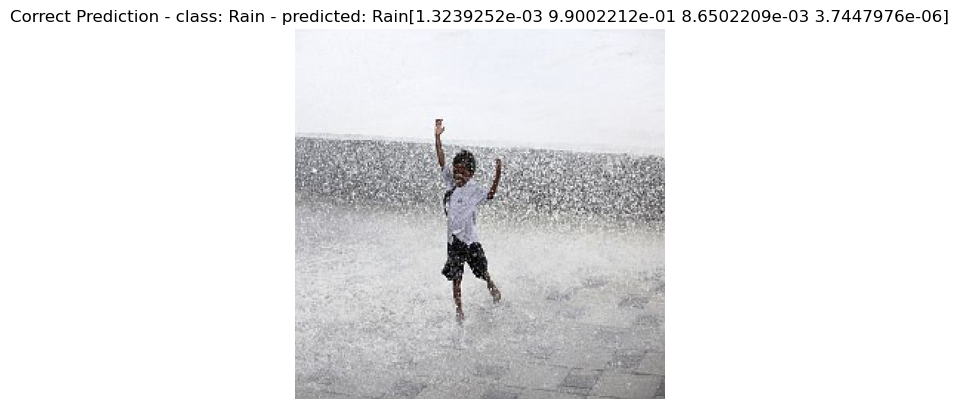

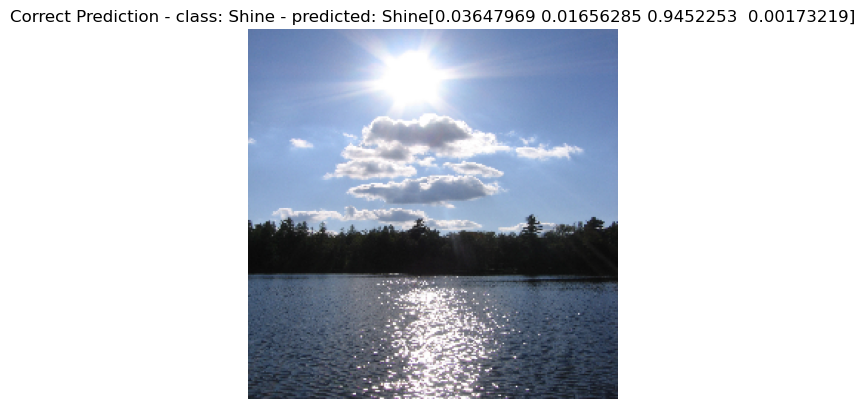

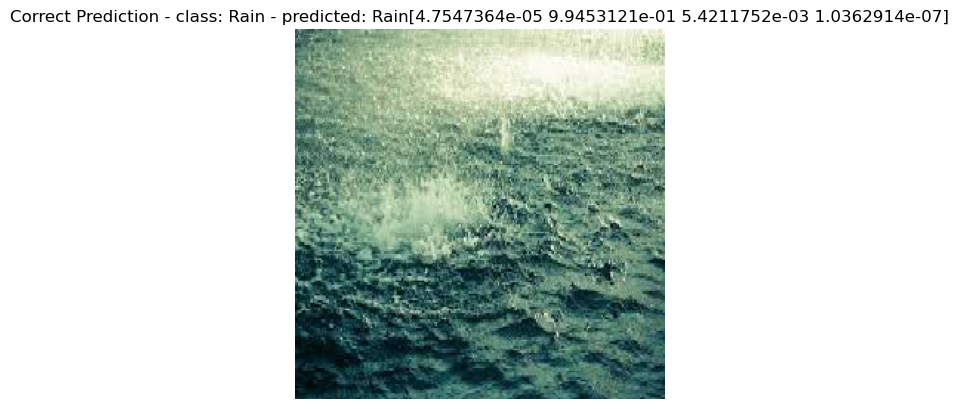

In [51]:
predict_one(model, 5) #<--you can show multiple pictures with this command. Just fill in the number you want to see.

## 4. CNN Model 3

In [53]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [54]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 50, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 501ms/step - accuracy: 0.4658 - loss: 0.1606 - val_accuracy: 0.4453 - val_loss: 0.1594
Epoch 2/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 6s 383ms/step - accuracy: 0.6875 - loss: 0.1181

C:\Users\daxma\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.6875 - loss: 0.1181 - val_accuracy: 0.4766 - val_loss: 0.1474
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 492ms/step - accuracy: 0.6528 - loss: 0.1220 - val_accuracy: 0.5312 - val_loss: 0.1900
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7188 - loss: 0.1190 - val_accuracy: 0.4062 - val_loss: 0.2105
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 490ms/step - accuracy: 0.5993 - loss: 0.1163 - val_accuracy: 0.7344 - val_loss: 0.1028
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7188 - loss: 0.1019 - val_accuracy: 0.6719 - val_loss: 0.1157
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 500ms/step - accuracy: 0.7329 - loss: 0.1051 - val_accuracy: 0.7422 - val_loss: 0.1107
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6875 - loss: 0.1152 - val_accuracy: 0.7578 - val_loss: 0.0981
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 519ms/step - accuracy: 0.7629 - loss: 0.0928 - val_accuracy: 0.6953 - val_lo

In [60]:
results = pd.DataFrame(model.history.history)

## 4.1 Evaluate Model

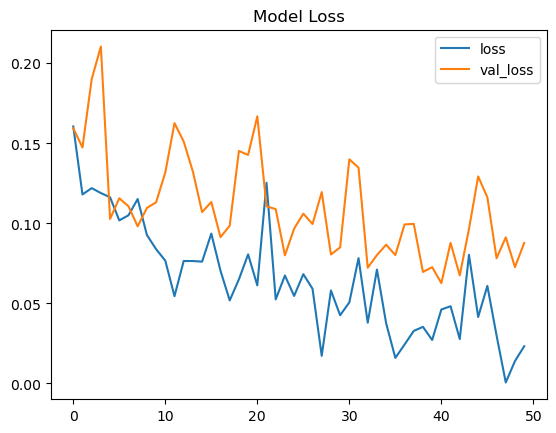

In [67]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

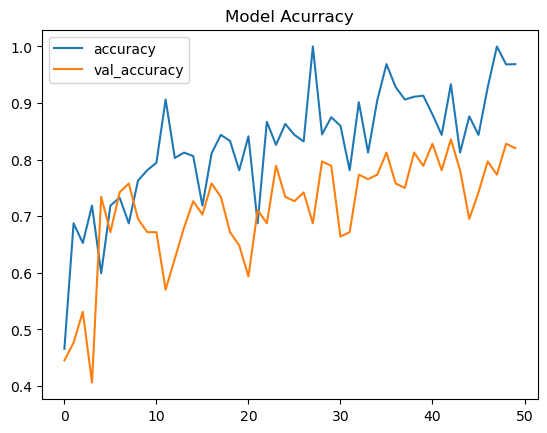

In [68]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [69]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.96875, Val_Accuracy: 0.8203125
Loss: 0.023220496252179146, Val_Loss: 0.08776463568210602


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step


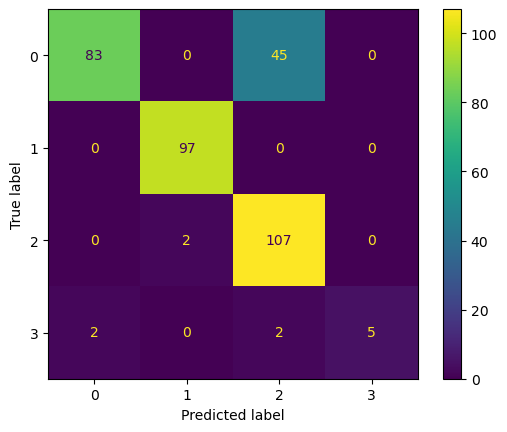

In [70]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [71]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


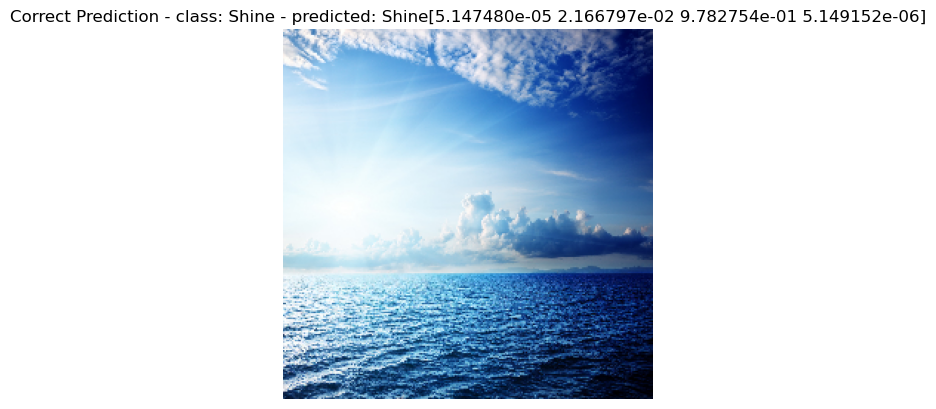

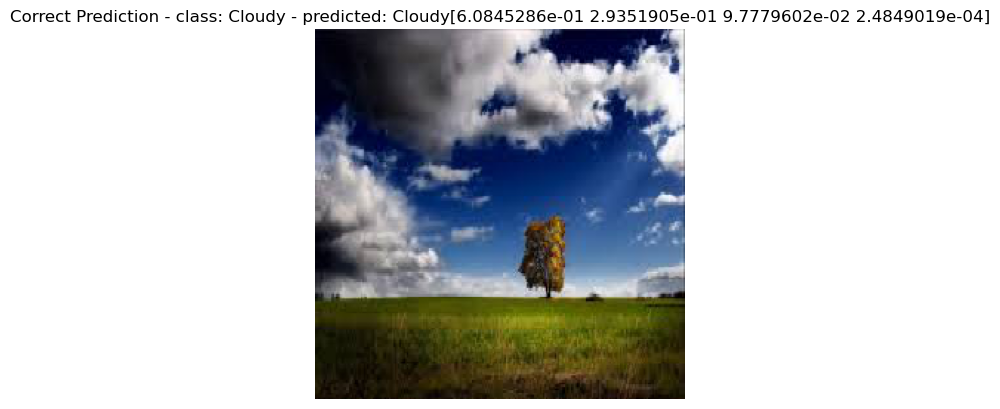

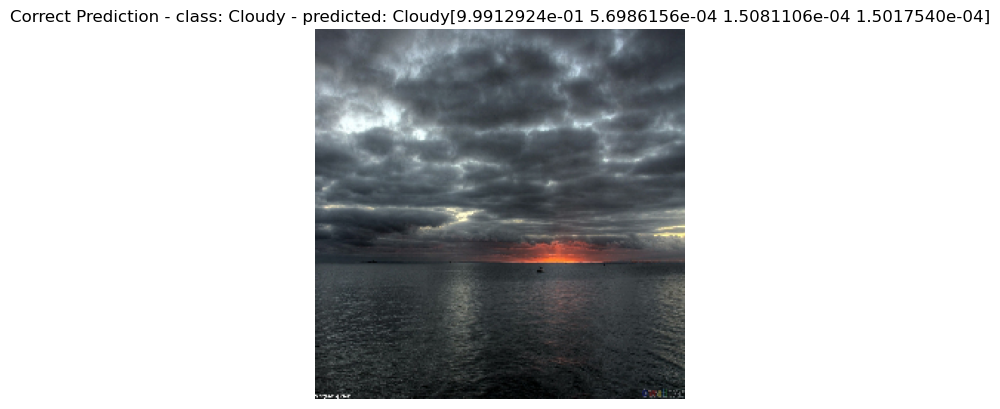

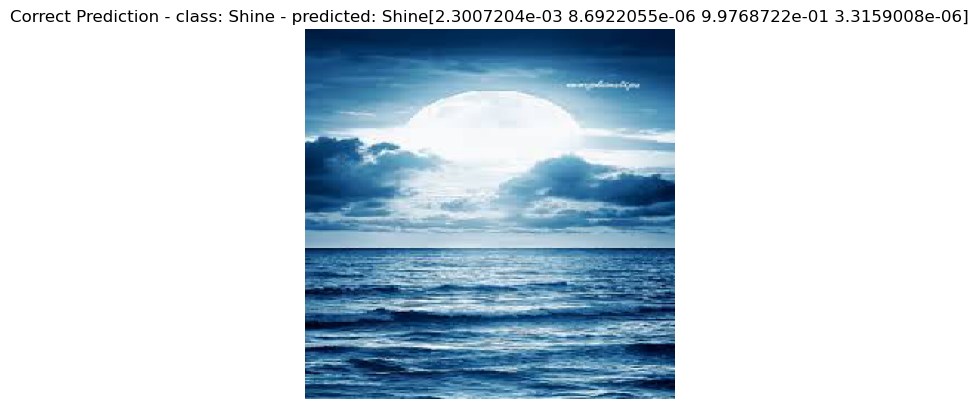

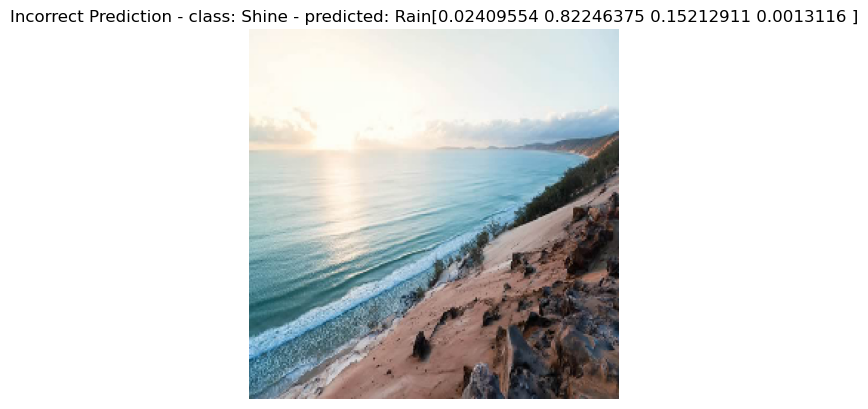

In [72]:
predict_one(model, 5) #<--you can show multiple pictures with this command. Just fill in the number you want to see.

## 5. CNN Model 4

In [74]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [76]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 60, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 524ms/step - accuracy: 0.8798 - loss: 0.0481 - val_accuracy: 0.7734 - val_loss: 0.0942
Epoch 2/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9688 - loss: 0.0176 - val_accuracy: 0.7656 - val_loss: 0.0932
Epoch 3/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 507ms/step - accuracy: 0.9533 - loss: 0.0201 - val_accuracy: 0.8203 - val_loss: 0.0802
Epoch 4/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9688 - loss: 0.0168 - val_accuracy: 0.8594 - val_loss: 0.0698
Epoch 5/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 497ms/step - accuracy: 0.9583 - loss: 0.0192 - val_accuracy: 0.8516 - val_loss: 0.0616
Epoch 6/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.9688 - loss: 0.0100 - val_accuracy: 0.8359 - val_loss: 0.0640
Epoch 7/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 488ms/step - accuracy: 0.9416 - loss: 0.0215 - val_accuracy: 0.8516 - val_loss: 0.0622
Epoch 8/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9375 - loss: 0.0250 - val_accuracy: 0.8

In [77]:
results = pd.DataFrame(model.history.history)

## 5.1 Evaluate Model

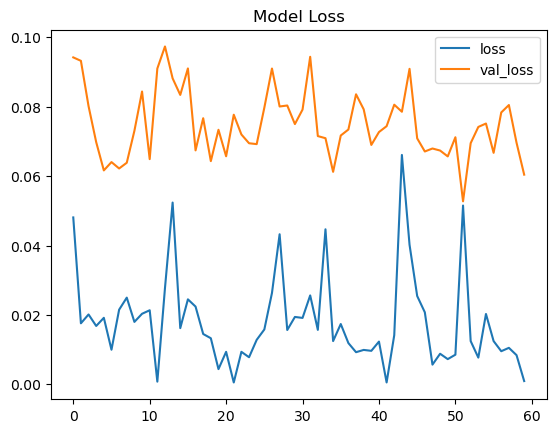

In [80]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

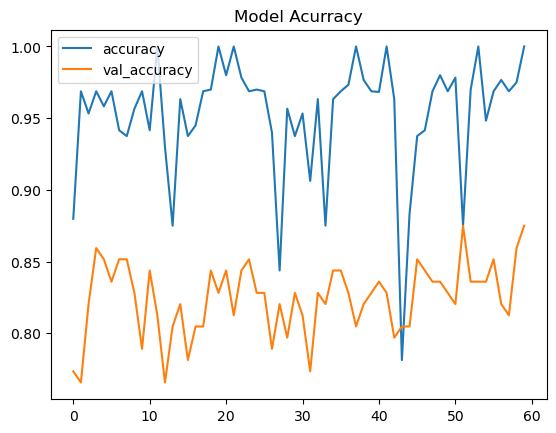

In [81]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [82]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 1.0, Val_Accuracy: 0.875
Loss: 0.0009359975811094046, Val_Loss: 0.06041871756315231


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step


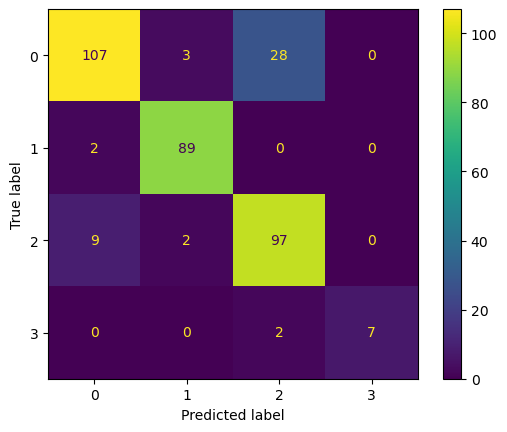

In [83]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [84]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


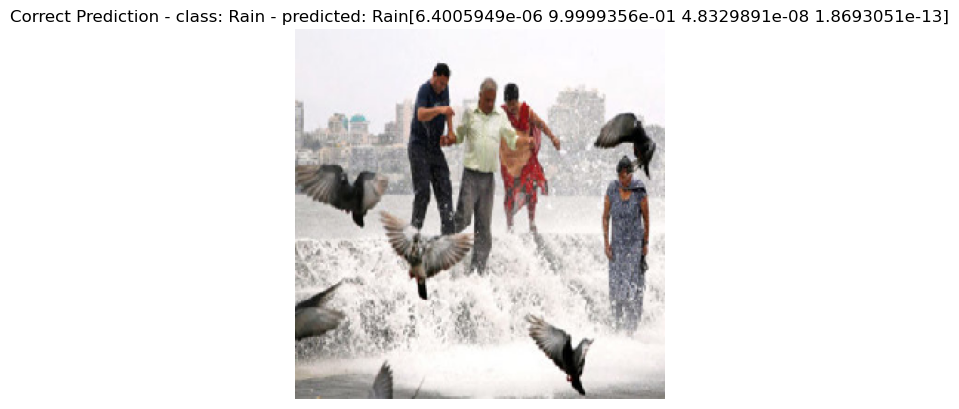

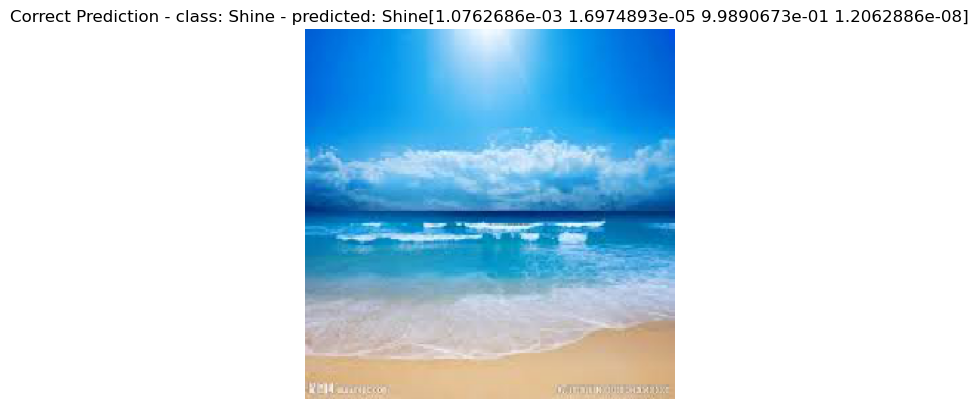

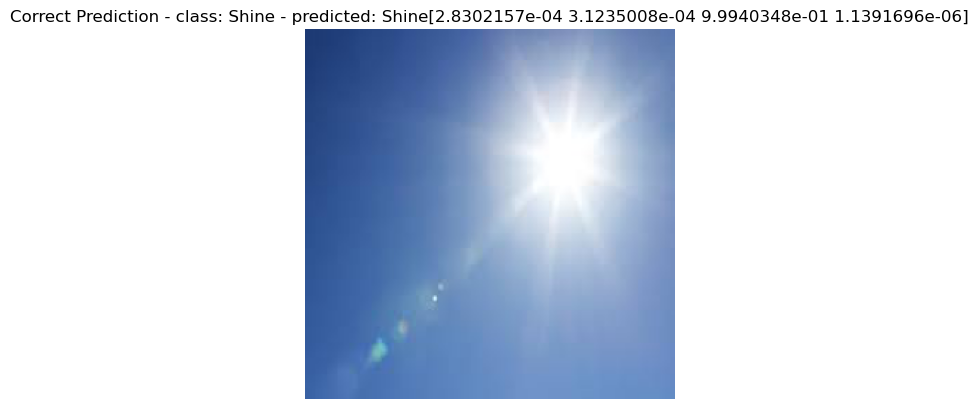

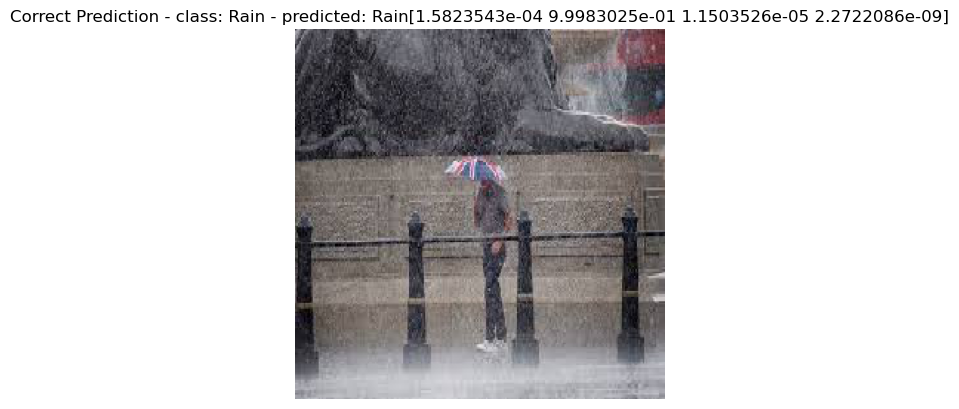

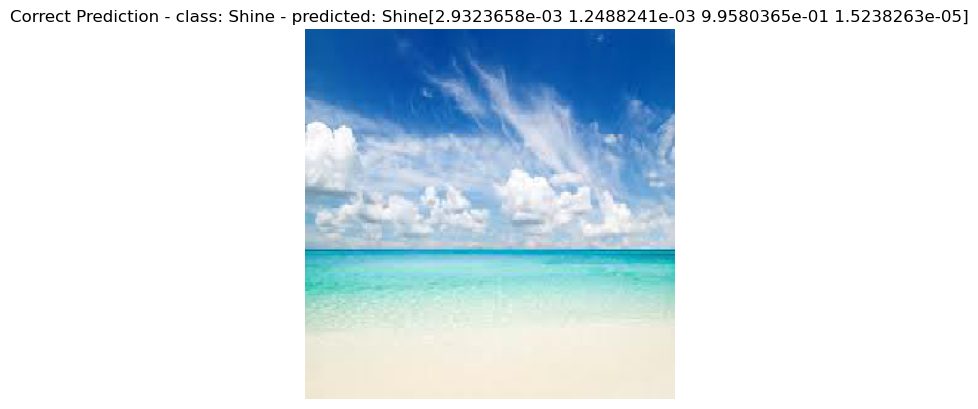

In [85]:
predict_one(model, 5) #<--you can show multiple pictures with this command. Just fill in the number you want to see.

## 6. CNN Model 5

In [106]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [108]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 75, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/75
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 537ms/step - accuracy: 0.5092 - loss: 0.1439 - val_accuracy: 0.5000 - val_loss: 0.1868
Epoch 2/75
 1/19 ━━━━━━━━━━━━━━━━━━━━ 7s 421ms/step - accuracy: 0.5625 - loss: 0.1567

C:\Users\daxma\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.5625 - loss: 0.1567 - val_accuracy: 0.5078 - val_loss: 0.1591
Epoch 3/75
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 470ms/step - accuracy: 0.7412 - loss: 0.1118 - val_accuracy: 0.7031 - val_loss: 0.1263
Epoch 4/75
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6875 - loss: 0.1017 - val_accuracy: 0.7422 - val_loss: 0.1233
Epoch 5/75
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 498ms/step - accuracy: 0.7412 - loss: 0.0996 - val_accuracy: 0.5938 - val_loss: 0.1459
Epoch 6/75
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.4688 - loss: 0.1514 - val_accuracy: 0.7344 - val_loss: 0.1146
Epoch 7/75
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 468ms/step - accuracy: 0.6878 - loss: 0.1278 - val_accuracy: 0.7109 - val_loss: 0.1133
Epoch 8/75
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7188 - loss: 0.1064 - val_accuracy: 0.7188 - val_loss: 0.1067
Epoch 9/75
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 472ms/step - accuracy: 0.7763 - loss: 0.0871 - val_accuracy: 0.6875 - val_loss

In [109]:
results = pd.DataFrame(model.history.history)

## 6.1 Evaluate Model

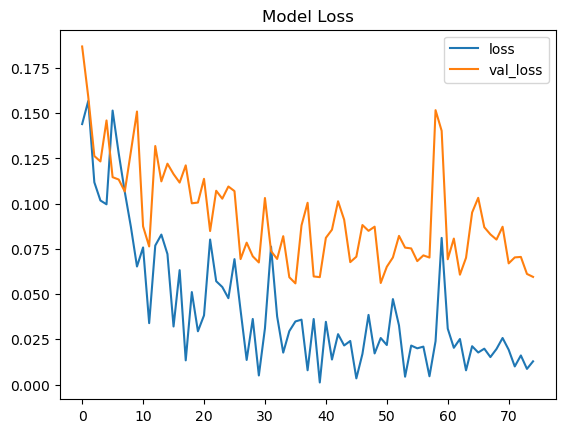

In [112]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

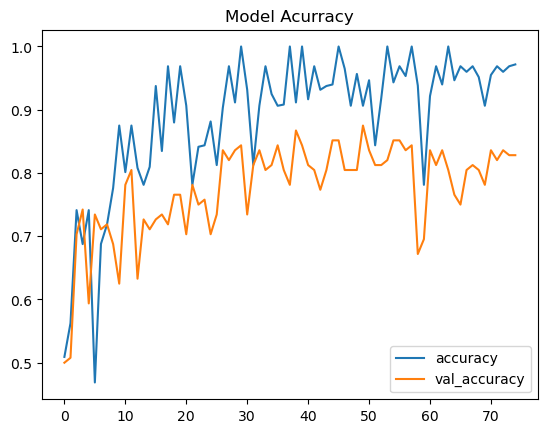

In [113]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [114]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.9716193675994873, Val_Accuracy: 0.828125
Loss: 0.012830334715545177, Val_Loss: 0.059495143592357635


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step


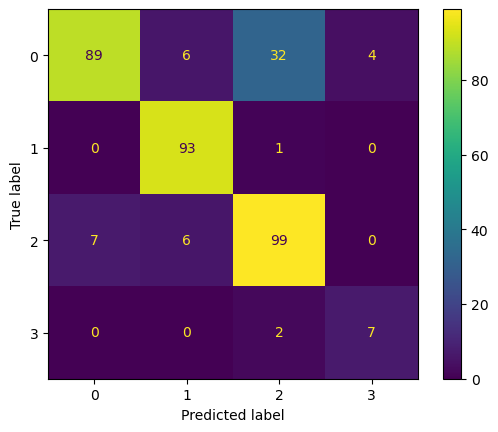

In [115]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [116]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


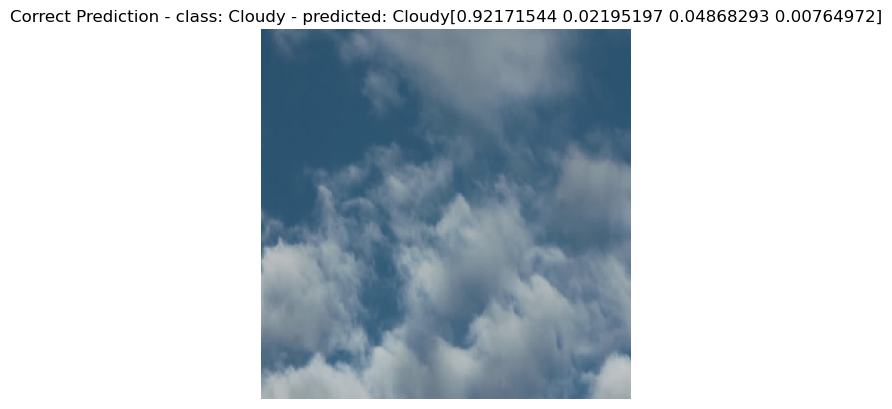

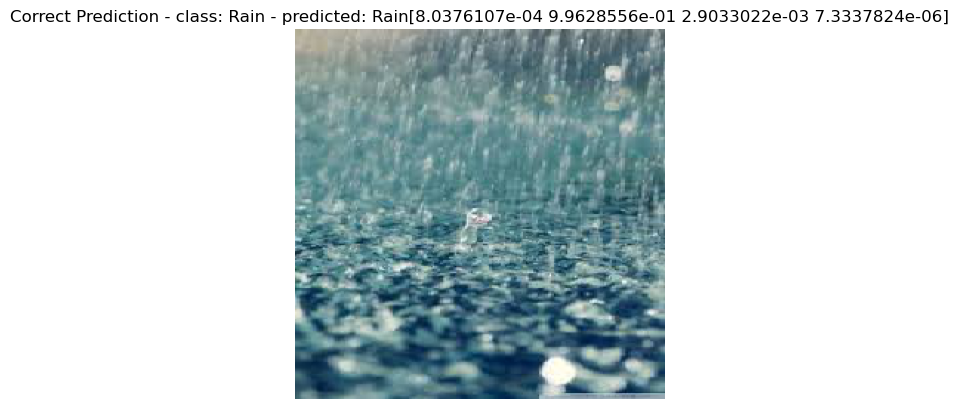

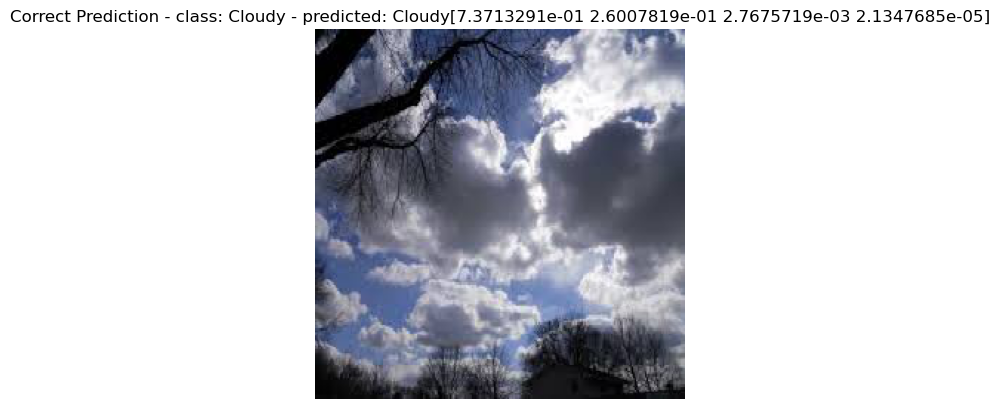

In [117]:
predict_one(model, 3) #<--you can show multiple pictures with this command. Just fill in the number you want to see.